<a href="https://colab.research.google.com/github/cjsdudwls1/2026_Spring_Data_Standardization/blob/main/4%EC%A3%BC%EC%B0%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 100번 동전 던지기 확률 계산

100번의 동전 던지기에서 특정한 순서쌍이 나타날 확률을 계산합니다.

In [1]:
import math

# 동전을 100번 던졌을 때 가능한 모든 경우의 수
total_outcomes = 2**100

# 특정 순서쌍 하나가 나올 확률
probability = 1 / total_outcomes

print(f"모든 경우의 수 (2^100): {total_outcomes}")
print(f"특정 순서쌍이 나올 확률: {probability:.2e}")
print(f"분수 형태: 1 / 2^100")

모든 경우의 수 (2^100): 1267650600228229401496703205376
특정 순서쌍이 나올 확률: 7.89e-31
분수 형태: 1 / 2^100


In [2]:
print(0.1+0.2)

0.30000000000000004


,합(k),PMF P(X=k),CDF F(k)
0,2,0.027778,0.027778
1,3,0.055556,0.083333
2,4,0.083333,0.166667
3,5,0.111111,0.277778
4,6,0.138889,0.416667
5,7,0.166667,0.583333
6,8,0.138889,0.722222
7,9,0.111111,0.833333
8,10,0.083333,0.916667
9,11,0.055556,0.972222


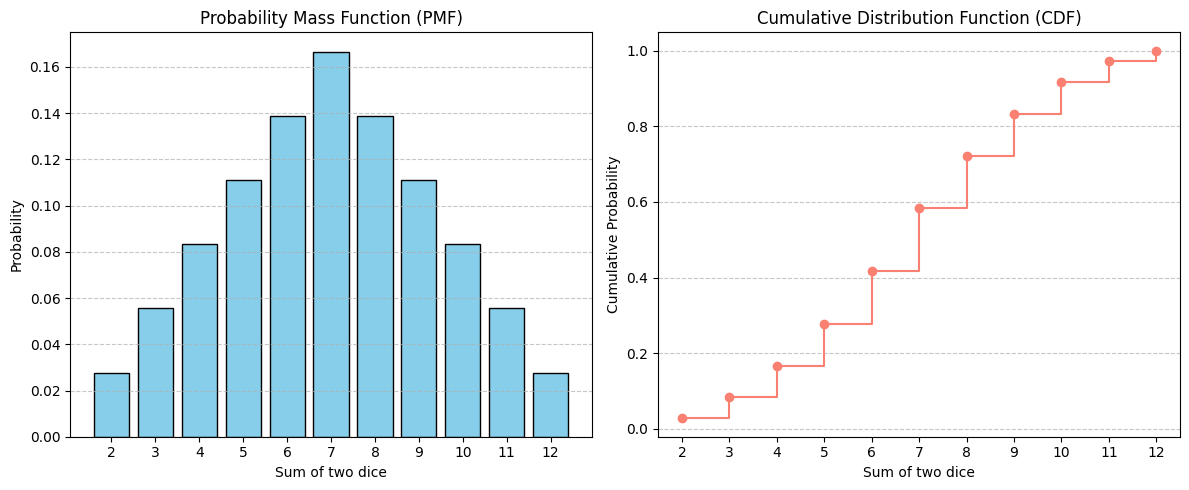

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 주사위 두 개의 모든 경우의 수 (6 * 6 = 36)
dice_sums = [i + j for i in range(1, 7) for j in range(1, 7)]
counts = pd.Series(dice_sums).value_counts().sort_index()

# PMF 계산
pmf = counts / len(dice_sums)

# CDF 계산
cdf = pmf.cumsum()

# 결과 출력
df_dist = pd.DataFrame({'합(k)': pmf.index, 'PMF P(X=k)': pmf.values, 'CDF F(k)': cdf.values})
display(df_dist)

# 시각화
plt.figure(figsize=(12, 5))

# PMF Plot
plt.subplot(1, 2, 1)
plt.bar(pmf.index, pmf.values, color='skyblue', edgecolor='black')
plt.title('Probability Mass Function (PMF)')
plt.xlabel('Sum of two dice')
plt.ylabel('Probability')
plt.xticks(range(2, 13))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# CDF Plot
plt.subplot(1, 2, 2)
plt.step(cdf.index, cdf.values, where='post', color='salmon', marker='o')
plt.title('Cumulative Distribution Function (CDF)')
plt.xlabel('Sum of two dice')
plt.ylabel('Cumulative Probability')
plt.xticks(range(2, 13))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

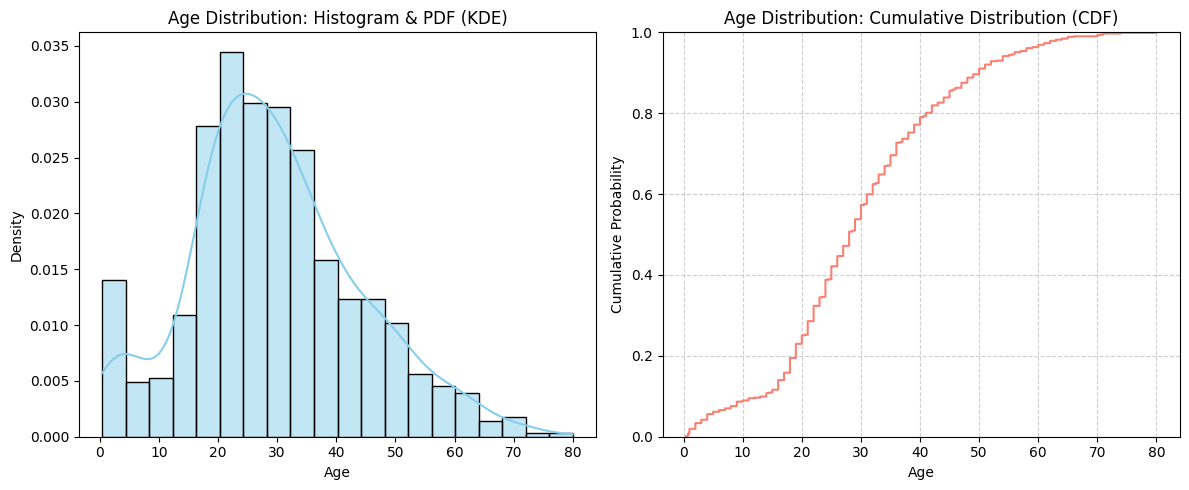

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 타이타닉 데이터 로드
titanic = sns.load_dataset('titanic')

# 'age' 컬럼에서 결측치 제거
age_data = titanic['age'].dropna()

# 시각화 설정
plt.figure(figsize=(12, 5))

# 1. 히스토그램 및 PDF (KDE)
plt.subplot(1, 2, 1)
sns.histplot(age_data, kde=True, stat="density", color='skyblue')
plt.title('Age Distribution: Histogram & PDF (KDE)')
plt.xlabel('Age')
plt.ylabel('Density')

# 2. CDF 시각화
plt.subplot(1, 2, 2)
sns.ecdfplot(age_data, color='salmon')
plt.title('Age Distribution: Cumulative Distribution (CDF)')
plt.xlabel('Age')
plt.ylabel('Cumulative Probability')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

앞서 보신 그래프 제목의 'KDE(커널 밀도 추정)'에서 쓰이는 **커널(Kernel)**에 대한 아주 훌륭한 질문입니다!

데이터 분석에서 커널은 쉽게 말해 **"각 데이터 포인트(점) 하나하나를 어떤 모양의 찰흙 덩어리로 바꿔서 쌓아 올릴 것인가?"**를 결정하는 '틀' 또는 '도장'과 같습니다.



수집된 데이터 점들 위에 각각 커널이라는 도장을 찍고, 그것들을 다 더해서 겹친 뒤 하나의 전체적인 분포(밀도) 곡선을 만드는 것이 바로 KDE의 원리입니다. 따라서 이 커널의 모양에 따라 모델이 추정하는 분포 곡선의 형태가 완전히 달라지게 됩니다.

### 1. 가우시안 커널 (Gaussian Kernel)
* **모양:** 중심이 높고 양옆으로 부드럽게 퍼지는 '종 모양(산 모양)'입니다. 흔히 아는 정규분포 곡선과 똑같이 생겼습니다.
* **모델에 주는 영향:** 데이터 포인트들을 아주 **매끄럽고 부드러운(Smooth) 곡선**으로 연결해 줍니다. 전체적인 추세나 흐름을 파악하기 좋습니다.
* **특징:** 양끝 꼬리가 0에 한없이 가까워지지만 완전히 0이 되지는 않기 때문에, 실제 데이터가 없는 외곽 구간에서도 밀도가 아주 미세하게 존재하는 것으로 모델링됩니다. 자연스러운 분포를 잘 표현하여 실무에서 **가장 기본적으로 널리 쓰이는 커널**입니다. (아까 보신 파란색 부드러운 곡선도 보통 가우시안 커널을 쓴 것입니다.)

### 2. 탑햇 커널 (Tophat Kernel)
* **모양:** 마술사 모자(Top hat)처럼 위가 평평한 '직사각형'입니다. 지정된 반경 안에서는 높이가 똑같고, 반경을 벗어나면 바로 0으로 뚝 떨어집니다.
* **모델에 주는 영향:** 부드러운 곡선이 아니라, 레고 블록이나 테트리스 블록을 쌓은 것처럼 **계단식으로 뚝뚝 끊어지고 뾰족뾰족한 형태**를 만듭니다.
* **특징:** 데이터 포인트 주변의 특정 반경 내에 있는 데이터만 똑같은 가중치로 취급하고, 그 밖의 데이터는 철저히 무시할 때 사용합니다.

### 3. 그 외의 커널 (Epanechnikov 등)
* **에파네치니코프(Epanechnikov) 커널**은 포물선 모양으로 생겼습니다. 가우시안처럼 부드럽게 이어지지만, 탑햇처럼 일정 범위를 벗어나면 값이 완전히 0으로 딱 떨어지는 형태입니다. 수학적으로 가장 효율적인 커널로 알려져 있습니다.

---

### 💡 한눈에 요약
커널 변환은 모델이 데이터의 분포를 그릴 때 **'얼마나 둥글고 부드럽게 선을 이어줄 것인가(형태)'**와 **'각 데이터 포인트가 주변에 어느 정도 범위까지 영향을 미칠 것인가(영향력)'**를 결정하는 역할을 합니다.

일반적으로는 직관적이고 부드러운 결과를 내는 **가우시안 커널**을 압도적으로 많이 사용하지만, 데이터가 뚝뚝 끊어지는 성질이 강하거나 특정 반경 밖의 값을 완전히 배제해야 할 때는 탑햇 같은 다른 모양의 도장(커널)으로 바꿔가며 모델을 조율하게 됩니다.

### 1. 베르누이 시행 (Bernoulli Trial)
동전을 한 번 던지는 행위처럼, 결과가 오직 두 가지(성공/실패, 앞면/뒷면)인 실험을 **베르누이 시행**이라고 합니다.
* 확률 변수 $X$: 앞면이면 1, 뒷면이면 0
* 성공 확률 $p = 0.5$

### 2. 이항 분포 (Binomial Distribution)
성공 확률이 $p$인 베르누이 시행을 $n$번 독립적으로 반복했을 때, 성공 횟수의 분포를 **이항분포**라고 하며 $B(n, p)$로 표기합니다.
* 여기서 $n = 100$, $p = 0.5$입니다.
* **확률 질량 함수 (PMF):** $P(X=k) = \binom{100}{k} (0.5)^k (0.5)^{100-k}$
* **평균 (Expected Value):** $E(X) = n \times p = 100 \times 0.5 = 50$번
* **분산 (Variance):** $Var(X) = n \times p \times (1-p) = 100 \times 0.5 \times 0.5 = 25$

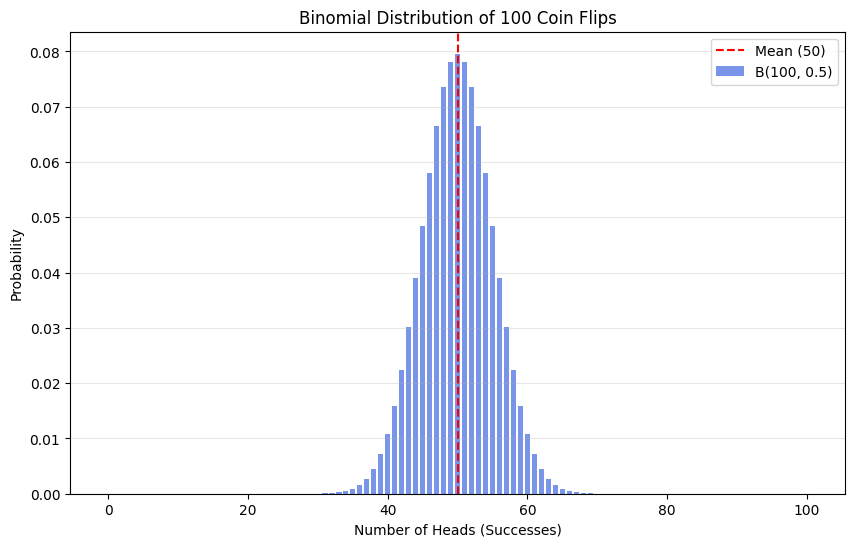

앞면이 정확히 50번 나올 확률: 0.0796
앞면이 40번에서 60번 사이로 나올 확률: 0.9648


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

n = 100
p = 0.5
x = np.arange(0, 101)

# 이항분포 확률 질량 함수(PMF) 계산
pmf_values = binom.pmf(x, n, p)

plt.figure(figsize=(10, 6))
plt.bar(x, pmf_values, color='royalblue', alpha=0.7, label=f'B({n}, {p})')
plt.title('Binomial Distribution of 100 Coin Flips')
plt.xlabel('Number of Heads (Successes)')
plt.ylabel('Probability')
plt.axvline(50, color='red', linestyle='--', label='Mean (50)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 특정 값 확인
print(f'앞면이 정확히 50번 나올 확률: {binom.pmf(50, n, p):.4f}')
print(f'앞면이 40번에서 60번 사이로 나올 확률: {sum(binom.pmf(k, n, p) for k in range(40, 61)):.4f}')

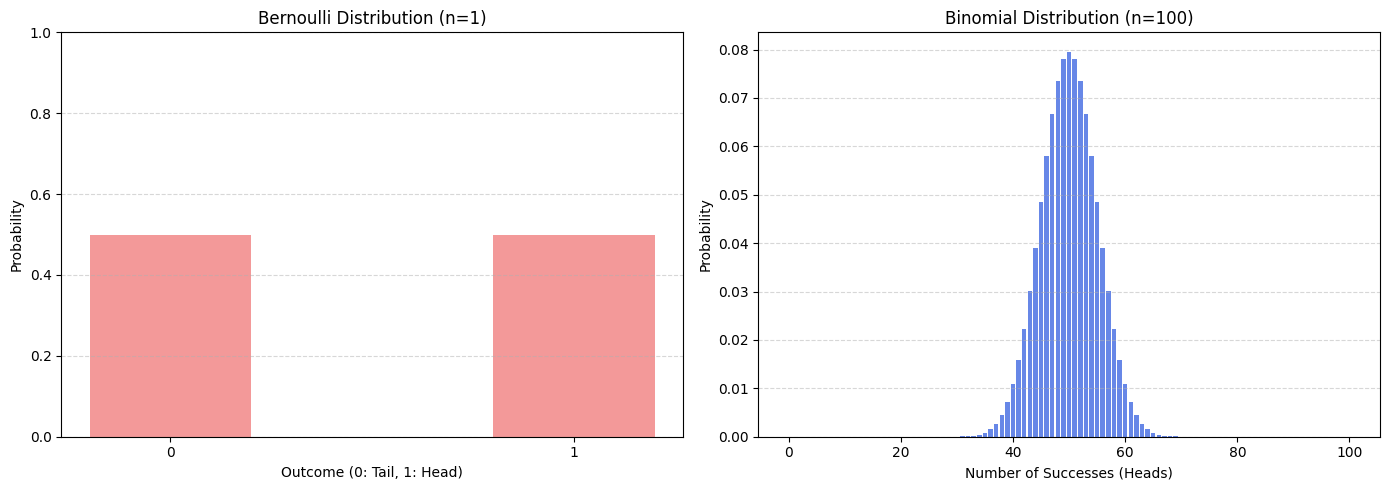

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli, binom

# 설정
p = 0.5
n_trials = 100

plt.figure(figsize=(14, 5))

# 1. 베르누이 분포 (동전 1번 던지기)
plt.subplot(1, 2, 1)
x_bernoulli = [0, 1]
plt.bar(x_bernoulli, bernoulli.pmf(x_bernoulli, p), color='lightcoral', alpha=0.8, width=0.4)
plt.title('Bernoulli Distribution (n=1)')
plt.xlabel('Outcome (0: Tail, 1: Head)')
plt.ylabel('Probability')
plt.xticks([0, 1])
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 2. 이항 분포 (동전 100번 던지기)
plt.subplot(1, 2, 2)
x_binom = np.arange(0, 101)
plt.bar(x_binom, binom.pmf(x_binom, n_trials, p), color='royalblue', alpha=0.8)
plt.title(f'Binomial Distribution (n={n_trials})')
plt.xlabel('Number of Successes (Heads)')
plt.ylabel('Probability')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 이론적 확률 vs 실제 시행(Simulation) 비교
이항분포 수식은 '이론'이고, 실제로 던져보는 것은 '실험'입니다. 100번씩 던지는 실험을 여러 번 반복하면 결국 이론적인 이항분포 모양으로 수렴하게 됩니다.

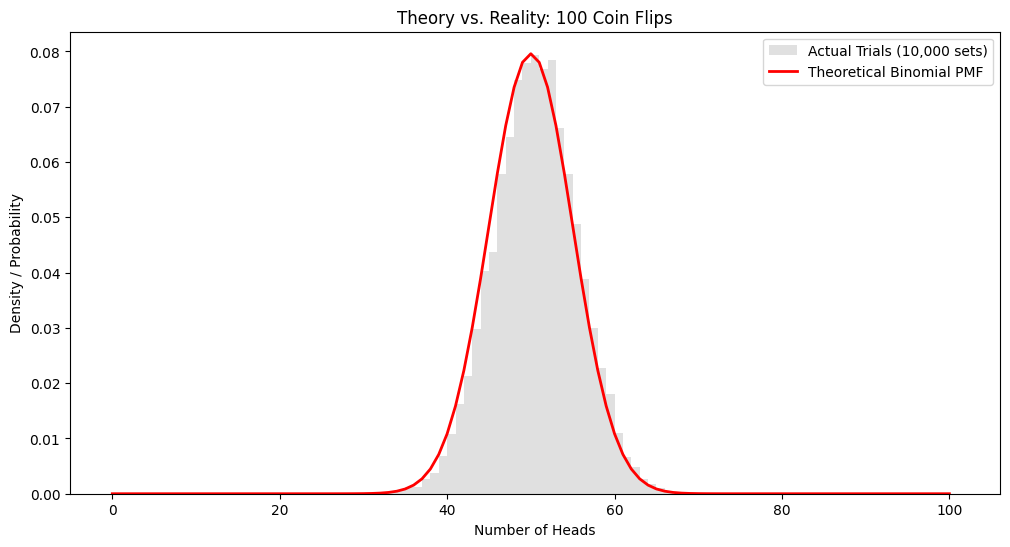

실제 10,000번 실험 중 무작위 한 번의 결과 (앞면 횟수): 49회


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

n, p = 100, 0.5

# 1. 이론적인 이항분포 (수식으로 계산)
x = np.arange(0, 101)
theory_pmf = binom.pmf(x, n, p)

# 2. 실제 시행 시뮬레이션 (100번 던지기를 10,000번 반복 수행)
# '시행'이 들어가는 부분입니다.
simulated_trials = np.random.binomial(n, p, size=10000)

plt.figure(figsize=(12, 6))

# 실제 시행 결과 히스토그램
plt.hist(simulated_trials, bins=range(102), density=True, color='lightgray', alpha=0.7, label='Actual Trials (10,000 sets)')

# 이론적 수식 라인
plt.plot(x, theory_pmf, 'r-', lw=2, label='Theoretical Binomial PMF')

plt.title('Theory vs. Reality: 100 Coin Flips')
plt.xlabel('Number of Heads')
plt.ylabel('Density / Probability')
plt.legend()
plt.show()

print(f"실제 10,000번 실험 중 무작위 한 번의 결과 (앞면 횟수): {np.random.choice(simulated_trials)}회")

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli, binom, norm
# 설정: 샘플 수 1000개
n_samples = 1000
# 1. 베르누이 분포 (p=0.5) : parameter
p_bern = 0.5
data_bern = bernoulli.rvs(p_bern, size=n_samples)
x_bern = [0, 1]
# 2. 이항 분포 (n=10, p=0.5) : parameter
n_bin, p_bin = 10, 0.5
data_bin = binom.rvs(n_bin, p_bin, size=n_samples)
x_bin = np.arange(0, n_bin + 1)
# 3. 정규 분포 (mu=0, sigma=1) : parameter
mu, std = 0, 1
data_norm = norm.rvs(mu, std, size=n_samples)
x_norm = np.linspace(-4, 4, 100)


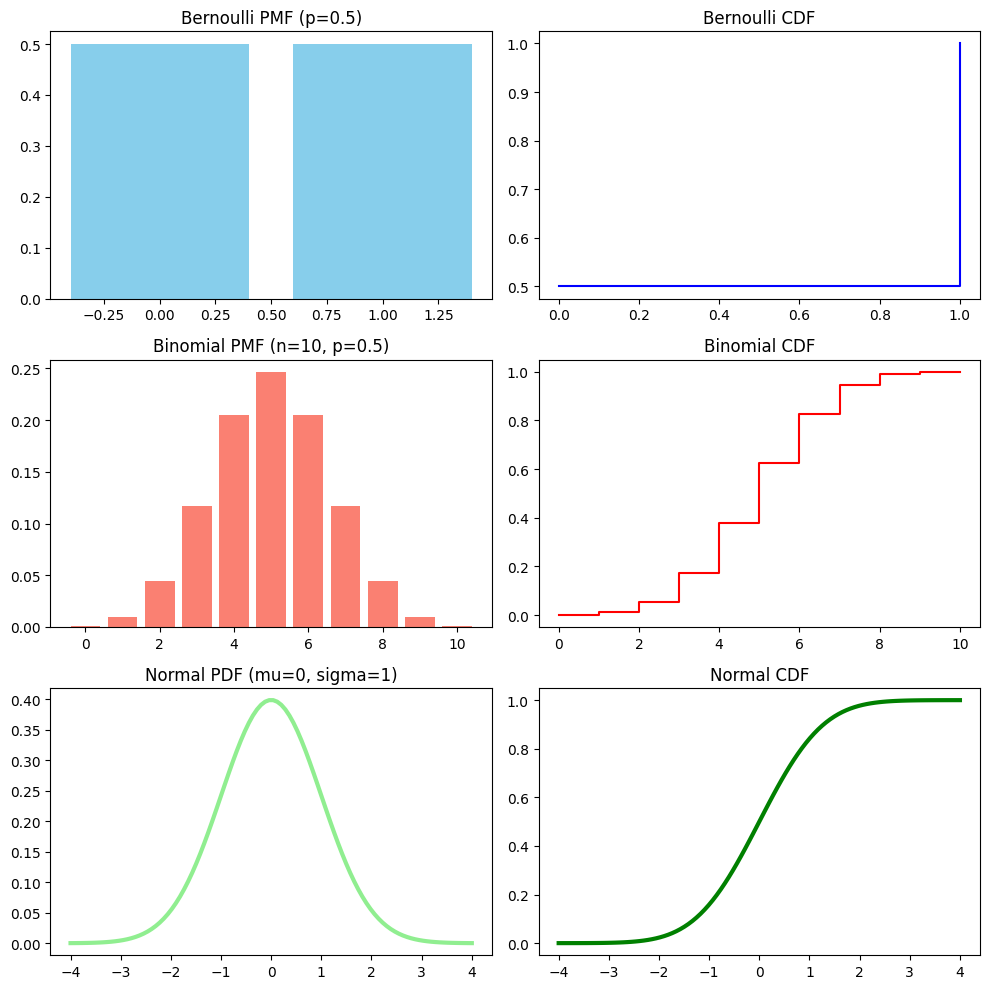

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
# --- Bernoulli ---
axes[0, 0].bar(x_bern, bernoulli.pmf(x_bern, p_bern), color='skyblue')
axes[0, 0].set_title(f"Bernoulli PMF (p={p_bern})")
axes[0, 1].step(x_bern, bernoulli.cdf(x_bern, p_bern), where='post', color='blue')
axes[0, 1].set_title("Bernoulli CDF")
# --- Binomial ---
axes[1, 0].bar(x_bin, binom.pmf(x_bin, n_bin, p_bin), color='salmon')
axes[1, 0].set_title(f"Binomial PMF (n={n_bin}, p={p_bin})")
axes[1, 1].step(x_bin, binom.cdf(x_bin, n_bin, p_bin), where='post', color='red')
axes[1, 1].set_title("Binomial CDF")
# --- Normal ---
axes[2, 0].plot(x_norm, norm.pdf(x_norm, mu, std), color='lightgreen', lw=3)
axes[2, 0].set_title(f"Normal PDF (mu={mu}, sigma={std})")
axes[2, 1].plot(x_norm, norm.cdf(x_norm, mu, std), color='green', lw=3)
axes[2, 1].set_title("Normal CDF")
plt.tight_layout()
plt.show()

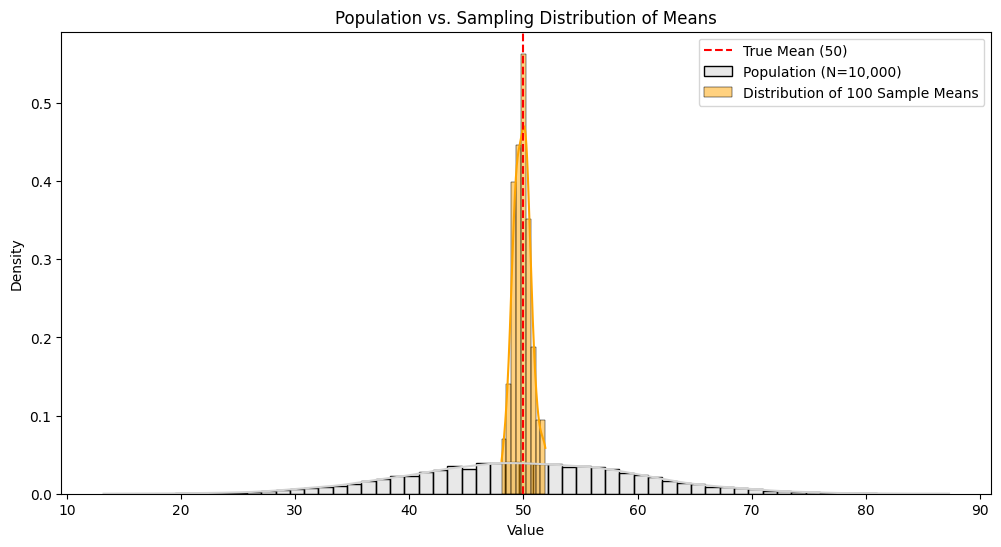

모집단 평균: 50.02
표본 평균들의 평균: 49.92


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 모집단 생성 (정규분포, 10,000개)
population_mu, population_std = 50, 10
population = np.random.normal(population_mu, population_std, 10000)

# 2. 샘플링 시행 (100개씩 100번)
sample_size = 100
n_samples = 100
sample_means = []

for _ in range(n_samples):
    sample = np.random.choice(population, size=sample_size, replace=False)
    sample_means.append(np.mean(sample))

# 3. 시각화
plt.figure(figsize=(12, 6))

# 모집단 분포
sns.histplot(population, kde=True, color='lightgray', stat="density", label='Population (N=10,000)')

# 표본 평균들의 분포
sns.histplot(sample_means, kde=True, color='orange', stat="density", label=f'Distribution of {n_samples} Sample Means')

plt.axvline(population_mu, color='red', linestyle='--', label=f'True Mean ({population_mu})')
plt.title('Population vs. Sampling Distribution of Means')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

print(f"모집단 평균: {np.mean(population):.2f}")
print(f"표본 평균들의 평균: {np.mean(sample_means):.2f}")

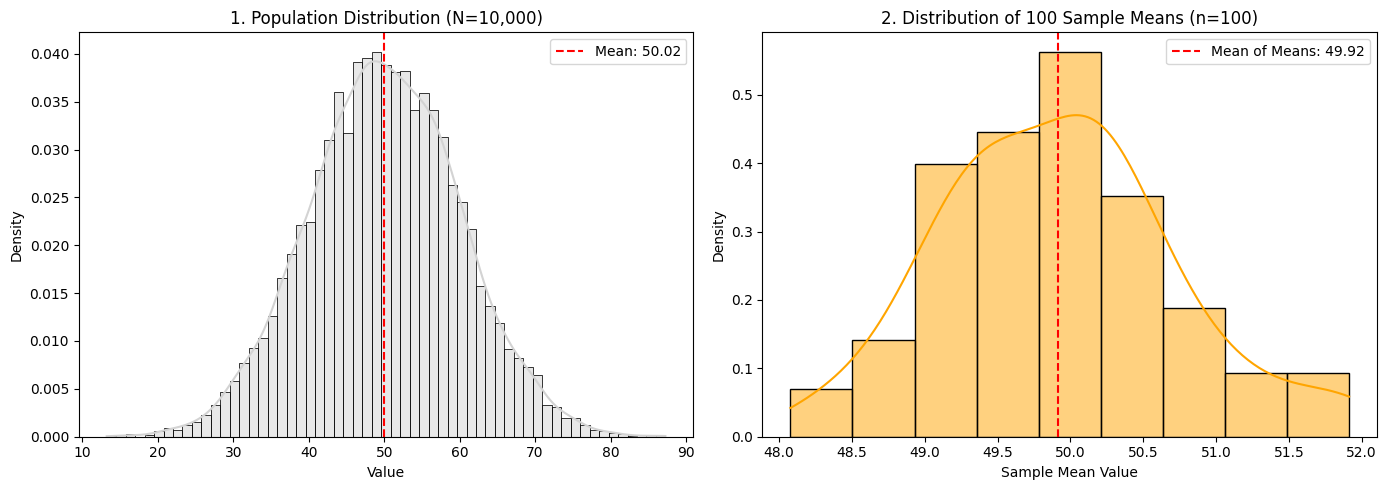

In [11]:
plt.figure(figsize=(14, 5))

# 1. 모집단의 분포 (Population Distribution)
plt.subplot(1, 2, 1)
sns.histplot(population, kde=True, color='lightgray', stat='density')
plt.axvline(population_mu, color='red', linestyle='--', label=f'Mean: {np.mean(population):.2f}')
plt.title('1. Population Distribution (N=10,000)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()

# 2. 표본 평균들의 분포 (Sampling Distribution of Means)
plt.subplot(1, 2, 2)
sns.histplot(sample_means, kde=True, color='orange', stat='density')
plt.axvline(np.mean(sample_means), color='red', linestyle='--', label=f'Mean of Means: {np.mean(sample_means):.2f}')
plt.title(f'2. Distribution of {n_samples} Sample Means (n={sample_size})')
plt.xlabel('Sample Mean Value')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.show()